# Pipeline NLP — Abstracts do arXiv

## Fase 1 — Pré-processamento

**Corpus:** 5 400 abstracts de 5 categorias do arXiv (`cs.LG`, `stat.ML`, `q-bio.NC`, `econ.EM`, `eess.SP`).

**Produto desta fase:** coluna `tokens_lemma` — sequência de lemas limpos por abstract — que alimenta todas as fases seguintes.

**Etapas:**
1. Carregamento e inspeção inicial
2. Limpeza de LaTeX
3. Tokenização (sentenças e palavras)
4. Remoção de stopwords
5. Stemming (Porter) × Lemmatização (spaCy) — comparação
6. POS tagging
7. Análise de impacto no vocabulário
8. Visualizações

> Execute as células de cima para baixo em ordem.


In [1]:
DOWNLOAD = False  # notebook reads local files only — never touches the network

import os
import re
import warnings
from collections import Counter

import matplotlib.pyplot as plt
import nltk
import pandas as pd
import seaborn as sns
import spacy
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import sent_tokenize, word_tokenize
from wordcloud import WordCloud

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 120)
plt.rcParams.update({'figure.dpi': 110, 'figure.figsize': (10, 4)})
os.makedirs('outputs', exist_ok=True)
print('Setup OK')


Setup OK


## 1.1 Carregamento e Inspeção Inicial


In [2]:
df = pd.read_parquet('data/corpus_raw.parquet')
print(f'Shape: {df.shape}')
df.head(2)


Shape: (5400, 6)


,id,title,abstract,primary_category,authors,published
0,2507.15774,Time Series Forecasting Through the Lens of Dynamics,"While deep learning is facing an homogenization across modalities led by Transformers, they are still challenged by ...",cs.LG,"[Alexis-Raja Brachet, Pierre-Yves Richard and C\'eline Hudelot]",2026-05-15
1,2510.27258,Higher-order Linear Attention,The quadratic cost of scaled dot-product attention is a central obstacle to scaling autoregressive language models t...,cs.LG,"[Yifan Zhang, Zhen Qin, Mengdi Wang, Quanquan Gu]",2026-05-15


In [3]:
print('Abstracts por categoria:')
print(df['primary_category'].value_counts().to_string())
print(f'\nTotal: {len(df)}')


Abstracts por categoria:
primary_category
cs.LG       2000
stat.ML     1200
eess.SP     1200
q-bio.NC     500
econ.EM      500

Total: 5400


In [4]:
df['n_words_raw'] = df['abstract'].str.split().str.len()

print('Estatísticas de comprimento (palavras brutas):')
print(df['n_words_raw'].describe().round(1).to_string())
print()
print('Média por categoria:')
print(df.groupby('primary_category')['n_words_raw'].mean().round(1)
        .sort_values(ascending=False).to_string())


Estatísticas de comprimento (palavras brutas):
count    5400.0
mean      176.7
std        44.1
min        14.0
25%       147.0
50%       176.0
75%       207.0
max       300.0

Média por categoria:
primary_category
q-bio.NC    189.4
cs.LG       182.6
eess.SP     177.7
stat.ML     171.1
econ.EM     151.5


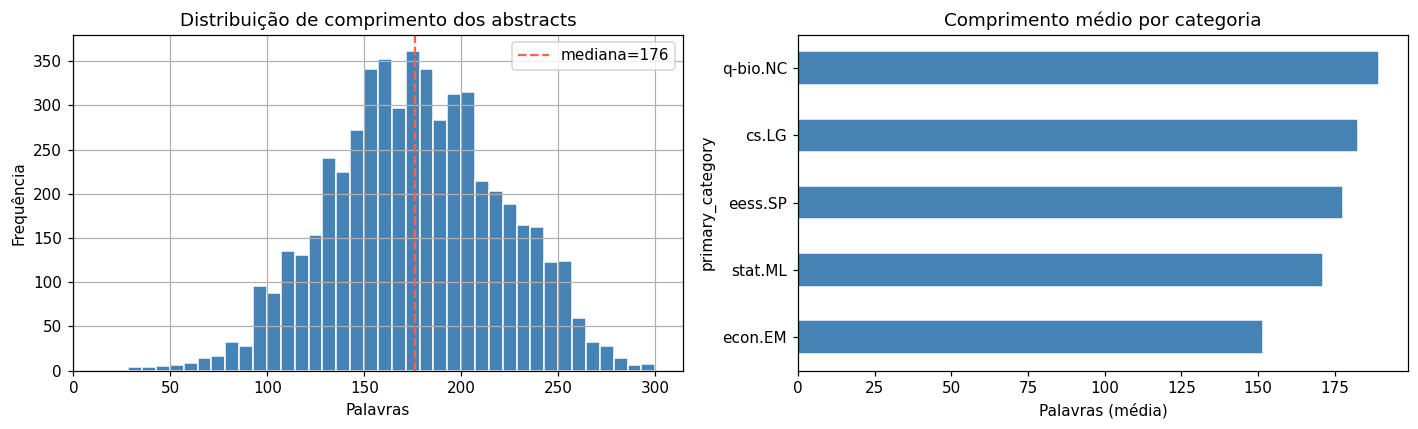

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df['n_words_raw'].hist(bins=40, ax=axes[0], color='steelblue', edgecolor='white')
med = df['n_words_raw'].median()
axes[0].axvline(med, color='tomato', linestyle='--', label=f'mediana={med:.0f}')
axes[0].set_title('Distribuição de comprimento dos abstracts')
axes[0].set_xlabel('Palavras'); axes[0].set_ylabel('Frequência')
axes[0].legend()

(df.groupby('primary_category')['n_words_raw'].mean()
   .sort_values()
   .plot.barh(ax=axes[1], color='steelblue', edgecolor='white'))
axes[1].set_title('Comprimento médio por categoria')
axes[1].set_xlabel('Palavras (média)')

plt.tight_layout()
plt.savefig('outputs/fig_abstract_lengths.png', bbox_inches='tight')
plt.show()


## 1.2 Limpeza de LaTeX

Abstracts do arXiv contêm marcação LaTeX extensiva: equações `$...$` e `$$...$$`,
citações `\cite{...}`, referências `\ref{...}`, comandos de formatação
(`\textbf`, `\emph`, `\mathbf`) e letras gregas avulsas (`\alpha`, `\beta`).

**Por que limpar antes de tokenizar?**
Sem limpeza o vocabulário enche de fragmentos sem conteúdo semântico:
`_{n}`, `\sigma_k`, `\mathbf`, `x^2`. Esses artefatos inflamam o tamanho
do vocabulário, prejudicam o TF-IDF e tornam os tópicos do LDA/NMF ilegíveis.
Esta etapa é crítica e deve anteceder qualquer tokenização.


In [6]:
def clean_latex(text: str) -> str:
    # display math $$...$$
    text = re.sub(r'\$\$.*?\$\$', ' ', text, flags=re.DOTALL)
    # inline math $...$
    text = re.sub(r'\$[^$\n]*?\$', ' ', text)
    # \cite{}, \ref{}, \label{}, \eqref{}
    text = re.sub(r'\\(?:cite|ref|label|eqref|bibitem)\{[^}]*\}', '', text, flags=re.IGNORECASE)
    # \begin{}...\end{} environments
    text = re.sub(r'\\begin\{[^}]*\}.*?\\end\{[^}]*\}', ' ', text, flags=re.DOTALL)
    # commands with arguments: \textbf{}, \mathbf{}, \emph{}
    text = re.sub(r'\\[a-zA-Z]+\{[^}]*\}', ' ', text)
    # remaining standalone commands: \alpha, \beta, \le
    text = re.sub(r'\\[a-zA-Z]+', ' ', text)
    # stray braces
    text = re.sub(r'[{}]', ' ', text)
    # collapse whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Demonstration on a LaTeX-heavy abstract
mask = df['abstract'].str.contains(r'\$', na=False)
raw_sample = df.loc[mask, 'abstract'].iloc[0]
print('ANTES:\n', raw_sample[:400])
print('\nDEPOIS:\n', clean_latex(raw_sample)[:400])


ANTES:
 While deep learning is facing an homogenization across modalities led by Transformers, they are still challenged by shallow linear models in the time series forecasting task. Our hypothesis is that models should learn a direct link from past to future data points, which we identify as a learning dynamics capability. We develop an original $\texttt{PRO-DYN}$ nomenclature to analyze existing models 

DEPOIS:
 While deep learning is facing an homogenization across modalities led by Transformers, they are still challenged by shallow linear models in the time series forecasting task. Our hypothesis is that models should learn a direct link from past to future data points, which we identify as a learning dynamics capability. We develop an original nomenclature to analyze existing models through the lens of


In [7]:
df['abstract_clean'] = df['abstract'].apply(clean_latex)

# Sanity-check: very few dollar signs should remain
remaining = df['abstract_clean'].str.contains(r'\$', na=False).sum()
print(f'Abstracts com "$" após limpeza: {remaining}  (esperado ≈ 0)')


Abstracts com "$" após limpeza: 3  (esperado ≈ 0)


## 1.3 Tokenização

Usamos NLTK para dois níveis:
- **Sentenças** (`sent_tokenize`): relevante para o NER da Fase 4.
- **Palavras** (`word_tokenize`): mantemos apenas tokens alfabéticos, em minúsculas. Pontuação, números e artefatos não-alfa são descartados aqui.


In [8]:
# Sentence tokenization — example
sample_clean = df['abstract_clean'].iloc[0]
sents = sent_tokenize(sample_clean)
print(f'Sentenças no 1.º abstract: {len(sents)}')
for s in sents[:3]:
    print(' •', s[:110])

# Word tokenization
def tokenize(text: str) -> list:
    return [t.lower() for t in word_tokenize(text) if t.isalpha()]

df['tokens_raw'] = df['abstract_clean'].apply(tokenize)

vocab_raw = len({t for toks in df['tokens_raw'] for t in toks})
avg_len   = df['tokens_raw'].apply(len).mean()
print(f'\nVocabulário bruto : {vocab_raw:,} tipos únicos')
print(f'Comprimento médio : {avg_len:.1f} tokens/abstract')


Sentenças no 1.º abstract: 6
 • While deep learning is facing an homogenization across modalities led by Transformers, they are still challeng
 • Our hypothesis is that models should learn a direct link from past to future data points, which we identify as
 • We develop an original nomenclature to analyze existing models through the lens of dynamics.



Vocabulário bruto : 21,835 tipos únicos
Comprimento médio : 165.7 tokens/abstract


## 1.4 Remoção de Stopwords

Combinamos duas listas:
- **NLTK English stopwords** (artigos, preposições, pronomes).
- **Stopwords de domínio** (customizadas): termos ubíquos em abstracts
  científicos sem poder discriminativo entre categorias — *paper*, *propose*,
  *result*, *approach*, *show*, *method*, *present*, *use*, *work*, *study*.

**O que NÃO removemos:** termos de conteúdo que são descritores temáticos
essenciais: *model*, *network*, *regression*, *learning*, *algorithm*,
*distribution*, *estimation*, *neural*, *graph*. Removê-los destruiria a
capacidade discriminativa do corpus entre as 5 categorias.


In [9]:
NLTK_STOPS = set(stopwords.words('english'))

DOMAIN_STOPS = {
    'paper', 'papers', 'propose', 'proposed', 'proposes', 'proposing',
    'result', 'results', 'approach', 'approaches',
    'show', 'shown', 'shows', 'showing',
    'work', 'works', 'working', 'study', 'studies',
    'present', 'presents', 'presented', 'presenting',
    'use', 'used', 'uses', 'using',
    'also', 'however', 'thus', 'hence',
    'new', 'well', 'two', 'one', 'three',
    'large', 'small', 'high', 'low', 'different', 'various',
    'et', 'al', 'e.g', 'i.e', 'fig', 'section', 'table', 'based',
    'task', 'tasks', 'base',
}

ALL_STOPS = NLTK_STOPS | DOMAIN_STOPS

def remove_stops(tokens: list) -> list:
    return [t for t in tokens if t not in ALL_STOPS and len(t) > 1]

df['tokens_filtered'] = df['tokens_raw'].apply(remove_stops)

vocab_filtered = len({t for toks in df['tokens_filtered'] for t in toks})
print(f'Vocabulário após stopwords: {vocab_filtered:,} tipos')
print(f'Redução: {(1 - vocab_filtered/vocab_raw)*100:.1f}% em relação ao bruto')

# Confirm content terms are retained
content_terms = ['model', 'network', 'regression', 'learning', 'neural',
                 'algorithm', 'distribution', 'estimation']
retained = [t for t in content_terms
            if any(t in toks for toks in df['tokens_filtered'])]
print(f'Termos de conteúdo retidos: {retained}')


Vocabulário após stopwords: 21,645 tipos
Redução: 0.9% em relação ao bruto
Termos de conteúdo retidos: ['model', 'network', 'regression', 'learning', 'neural', 'algorithm', 'distribution', 'estimation']


## 1.5 Stemming (Porter) × Lemmatização (spaCy)

Comparamos as duas abordagens medindo o impacto no vocabulário.

**Porter Stemming** — trunca sufixos por regras heurísticas, sem contexto.
Produz o vocabulário mais compacto, mas com raízes deformadas:
*regression → regress*, *optimizing → optim*, *distribution → distribut*.
A perda de legibilidade compromete o topic modeling: tópicos com raízes
deformadas são difíceis de interpretar e de narrar para o stakeholder.

**Lemmatização (spaCy, `en_core_web_sm`)** — usa o morfema canônico com
contexto de POS tag, preservando a legibilidade:
*networks → network*, *algorithms → algorithm*, *optimizing → optimize*.

**Decisão: adotamos lemmatização no pipeline final.**
Justificativa: o topic modeling (LDA/NMF), o motor de busca TF-IDF e o grafo
de co-ocorrência dependem de termos interpretáveis. Stemming produziria
tópicos com raízes deformadas inacessíveis ao stakeholder não técnico.
O stemming entra aqui apenas como referência comparativa.


In [10]:
ps = PorterStemmer()

def stem_tokens(tokens: list) -> list:
    return [ps.stem(t) for t in tokens]

df['tokens_stemmed'] = df['tokens_filtered'].apply(stem_tokens)

vocab_stemmed = len({t for toks in df['tokens_stemmed'] for t in toks})
print(f'Vocabulário após stemming (Porter): {vocab_stemmed:,} tipos')

print('\nTransformações — stemming:')
for w in ['regression', 'networks', 'learning', 'algorithms',
          'optimizing', 'distributed', 'estimation', 'neural']:
    print(f'  {w:22s} → {ps.stem(w)}')


Vocabulário após stemming (Porter): 13,701 tipos

Transformações — stemming:
  regression             → regress
  networks               → network
  learning               → learn
  algorithms             → algorithm
  optimizing             → optim
  distributed            → distribut
  estimation             → estim
  neural                 → neural


In [11]:
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

print('Processando com spaCy (batch_size=256) ...')
docs = list(nlp.pipe(df['abstract_clean'], batch_size=256))
print(f'Concluído — {len(docs)} documentos.')

LEMMA_MAP = {'datum': 'data'}

def lemmatize_doc(doc) -> list:
    return [
        LEMMA_MAP.get(token.lemma_.lower(), token.lemma_.lower())
        for token in doc
        if token.is_alpha
        and token.lemma_.lower() not in ALL_STOPS
        and len(token.lemma_) > 1
    ]

df['tokens_lemma'] = [lemmatize_doc(doc) for doc in docs]

vocab_lemma = len({t for toks in df['tokens_lemma'] for t in toks})
print(f'Vocabulário após lemmatização: {vocab_lemma:,} tipos')

print('\nTransformações — lemma (spaCy):')
for w in ['regression', 'networks', 'learning', 'algorithms',
          'optimizing', 'distributed', 'estimation', 'neural']:
    lema = list(nlp(w))[0].lemma_.lower()
    print(f'  {w:22s} → {lema}')


Processando com spaCy (batch_size=256) ...


Concluído — 5400 documentos.


Vocabulário após lemmatização: 18,931 tipos

Transformações — lemma (spaCy):
  regression             → regression
  networks               → network
  learning               → learn
  algorithms             → algorithm
  optimizing             → optimize
  distributed            → distribute
  estimation             → estimation
  neural                 → neural


## 1.6 POS Tagging com spaCy

Extraímos a distribuição de categorias gramaticais (Universal POS tags) sobre
o corpus completo usando os `doc` objects já calculados na célula anterior.

**O que esperamos:** abstracts científicos têm perfil nominal denso — alto
percentual de substantivos (NOUN) e adjetivos (ADJ) frente a verbos (VERB),
reflexo da linguagem descritiva técnica.

A distribuição de POS será relevante na **Fase 4** (NER e grafo de conceitos),
onde usaremos noun chunks para candidatos a termos técnicos.


  POS  Frequência
 NOUN      314478
  ADJ      139099
 VERB      129923
  ADP      111884
  DET       89080
PROPN       48764
CCONJ       34338
  ADV       32888
 PRON       28005
  AUX       22993
SCONJ       14608
 PART       11376
  NUM        4359
    X         253
PUNCT          31
  SYM          12
 INTJ          12


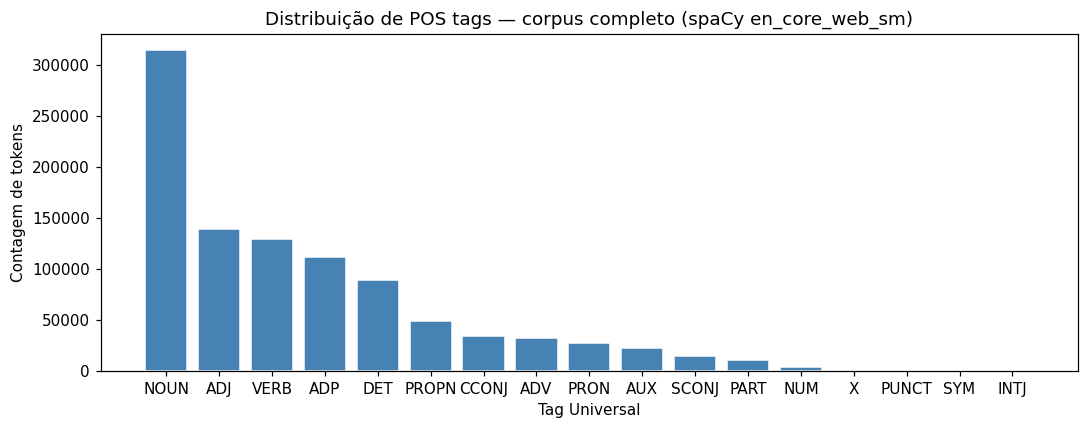


NOUN representa 32.0% de todos os tokens alfa


In [12]:
pos_counts = Counter(
    token.pos_
    for doc in docs
    for token in doc
    if token.is_alpha
)
pos_df = (pd.DataFrame(pos_counts.items(), columns=['POS', 'Frequência'])
            .sort_values('Frequência', ascending=False)
            .reset_index(drop=True))

print(pos_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(pos_df['POS'], pos_df['Frequência'], color='steelblue', edgecolor='white')
ax.set_title('Distribuição de POS tags — corpus completo (spaCy en_core_web_sm)')
ax.set_xlabel('Tag Universal'); ax.set_ylabel('Contagem de tokens')
plt.tight_layout()
plt.savefig('outputs/fig_pos_distribution.png', bbox_inches='tight')
plt.show()

noun_pct = pos_counts['NOUN'] / sum(pos_counts.values()) * 100
print(f'\nNOUN representa {noun_pct:.1f}% de todos os tokens alfa')


## 1.7 Análise de Impacto no Vocabulário


In [13]:
vocab_raw      = len({t for toks in df['tokens_raw']      for t in toks})
vocab_filtered = len({t for toks in df['tokens_filtered']  for t in toks})
vocab_stemmed  = len({t for toks in df['tokens_stemmed']   for t in toks})
vocab_lemma    = len({t for toks in df['tokens_lemma']     for t in toks})

summary = pd.DataFrame({
    'Etapa': [
        'Tokenização bruta (alpha, lower)',
        'Após remoção de stopwords',
        'Após stemming (Porter)',
        'Após lemmatização (spaCy)',
    ],
    'Tokens únicos': [vocab_raw, vocab_filtered, vocab_stemmed, vocab_lemma],
    'Redução vs bruto': [
        '—',
        f'{(1 - vocab_filtered/vocab_raw)*100:.1f}%',
        f'{(1 - vocab_stemmed/vocab_raw)*100:.1f}%',
        f'{(1 - vocab_lemma/vocab_raw)*100:.1f}%',
    ],
})
print(summary.to_string(index=False))


                           Etapa  Tokens únicos Redução vs bruto
Tokenização bruta (alpha, lower)          21835                —
       Após remoção de stopwords          21645             0.9%
          Após stemming (Porter)          13701            37.3%
       Após lemmatização (spaCy)          18931            13.3%


### Interpretação

- **Stopwords** removem os termos de alta frequência e baixo conteúdo. A magnitude depende da fração de hápax (palavras que aparecem uma só vez), que não são afetados pela lista de stopwords.
- **Stemming (Porter)** produz a maior compressão de vocabulário, mas ao custo de legibilidade: raízes como *optim*, *regress* e *distribut* não são palavras interpretáveis. No topic modeling isso geraria tópicos difíceis de comunicar.
- **Lemmatização (spaCy)** oferece compressão moderada com preservação total da legibilidade. O lema *network* (de *networks*, *networking*) é imediatamente compreensível; o mesmo vale para *algorithm*, *learn*, *distribute*.

**Escolha consolidada:** `tokens_lemma` é a representação adotada nas fases 2–5 do pipeline.


## 1.8 Visualizações


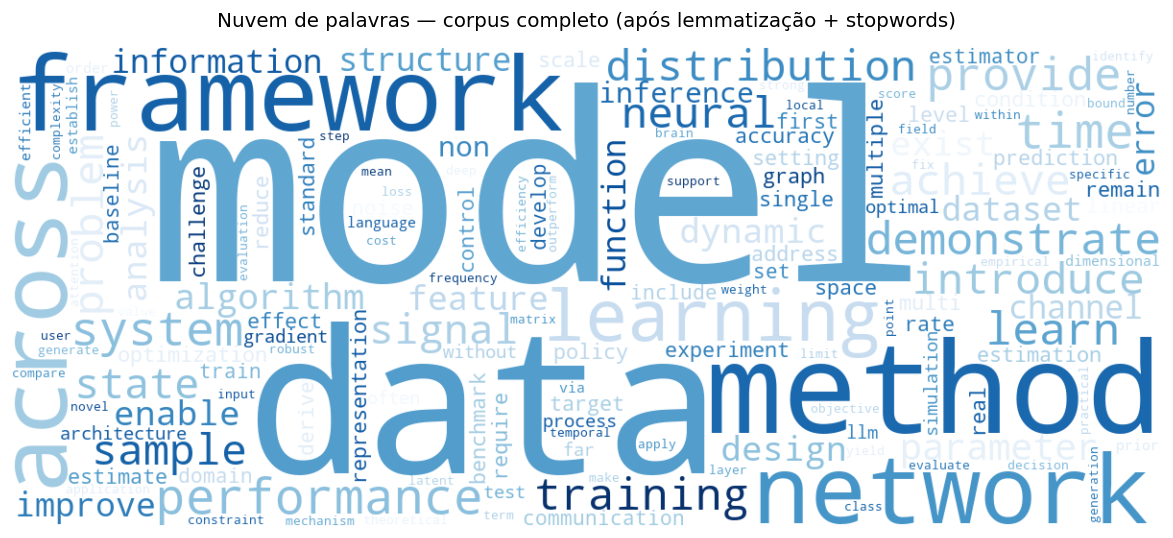

Stopwords de domínio ausentes da nuvem (amostra): ['paper', 'propose', 'result', 'approach', 'show']


In [14]:
all_lemmas = ' '.join(t for toks in df['tokens_lemma'] for t in toks)

wc = WordCloud(
    width=1200, height=500,
    background_color='white',
    max_words=150,
    colormap='Blues_r',
    collocations=False,
).generate(all_lemmas)

fig, ax = plt.subplots(figsize=(14, 5))
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
ax.set_title(
    'Nuvem de palavras — corpus completo (após lemmatização + stopwords)',
    pad=14, fontsize=13
)
plt.tight_layout()
plt.savefig('outputs/fig_wordcloud.png', bbox_inches='tight')
plt.show()

# Confirm domain stopwords are absent
absent = [t for t in ['paper', 'propose', 'result', 'approach', 'show']
          if t not in all_lemmas.split()[:5000]]
print('Stopwords de domínio ausentes da nuvem (amostra):', absent)


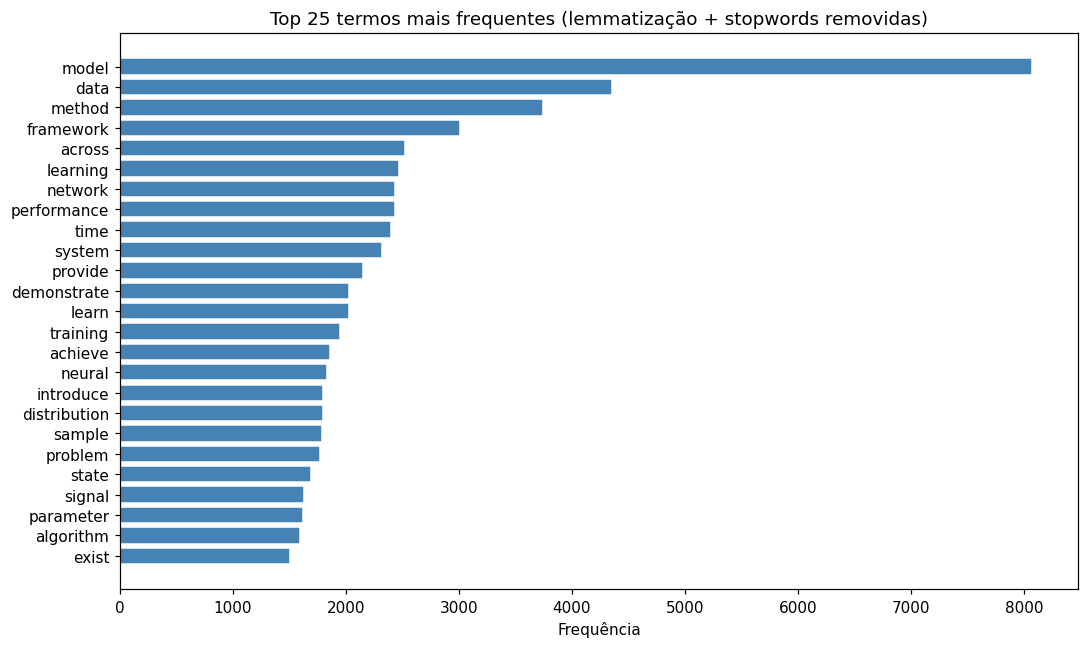

In [15]:
TOP_N = 25
counter = Counter(t for toks in df['tokens_lemma'] for t in toks)
terms, freqs = zip(*counter.most_common(TOP_N))

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(TOP_N), freqs[::-1], color='steelblue', edgecolor='white')
ax.set_yticks(range(TOP_N))
ax.set_yticklabels(terms[::-1])
ax.set_title(f'Top {TOP_N} termos mais frequentes (lemmatização + stopwords removidas)')
ax.set_xlabel('Frequência')
plt.tight_layout()
plt.savefig('outputs/fig_top_terms.png', bbox_inches='tight')
plt.show()


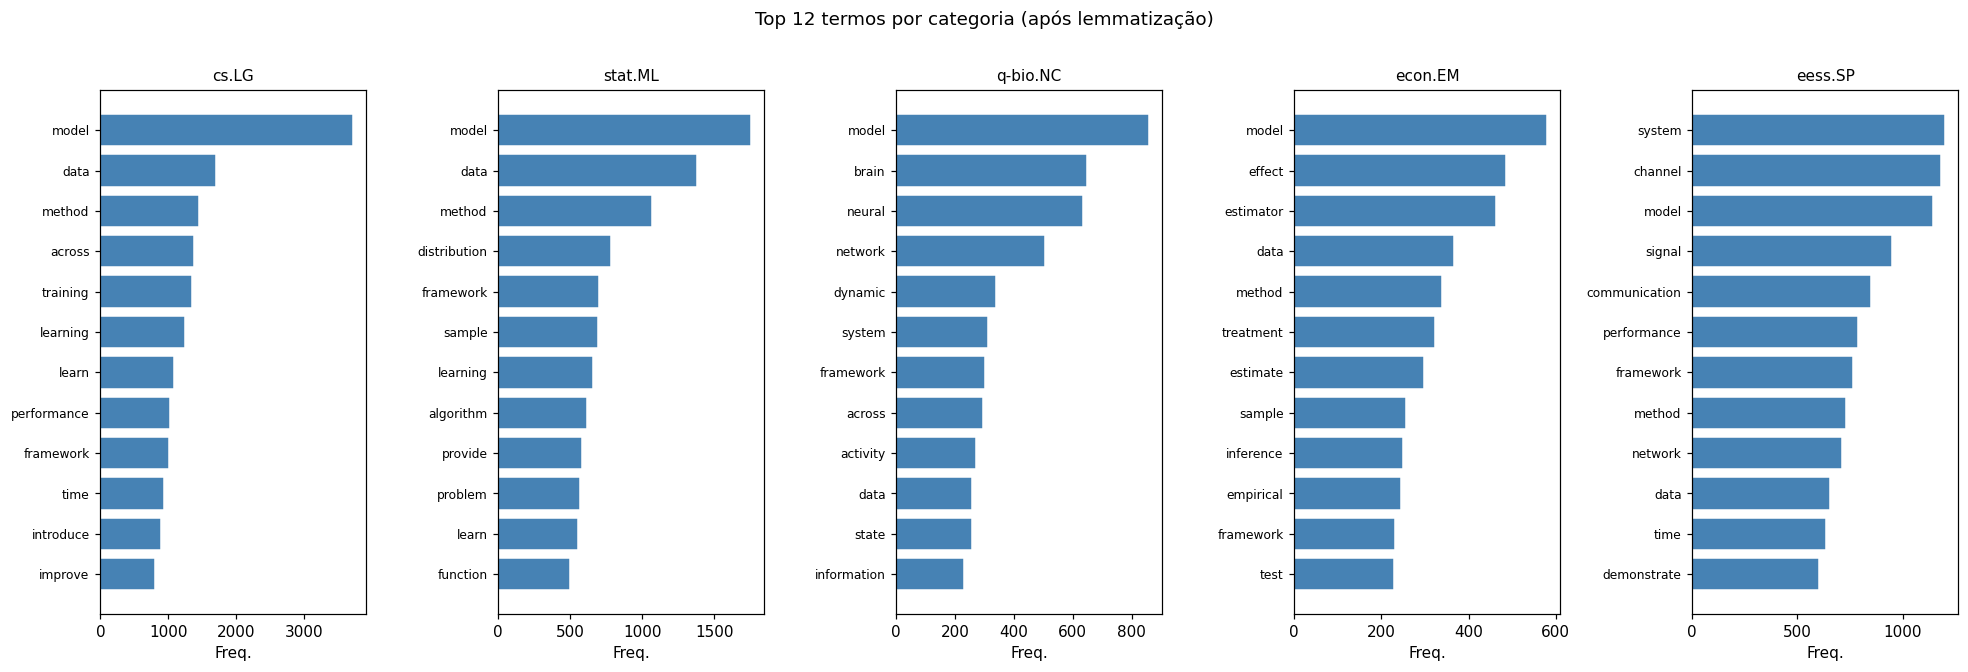

In [16]:
cats = ['cs.LG', 'stat.ML', 'q-bio.NC', 'econ.EM', 'eess.SP']
fig, axes = plt.subplots(1, 5, figsize=(18, 6))

for ax, cat in zip(axes, cats):
    sub = df[df['primary_category'] == cat]['tokens_lemma']
    cnt = Counter(t for toks in sub for t in toks)
    top = cnt.most_common(12)
    ts, fs = zip(*top)
    ax.barh(range(len(ts)), fs[::-1], color='steelblue', edgecolor='white')
    ax.set_yticks(range(len(ts)))
    ax.set_yticklabels(ts[::-1], fontsize=8)
    ax.set_title(cat, fontsize=10)
    ax.set_xlabel('Freq.')

plt.suptitle('Top 12 termos por categoria (após lemmatização)', y=1.01, fontsize=12)
plt.tight_layout()
plt.savefig('outputs/fig_top_terms_by_cat.png', bbox_inches='tight')
plt.show()


## Saída da Fase 1

Salvamos o dataframe aumentado com `text_preprocessed` (lemas unidos por espaço)
e `tokens_lemma` (lista de tokens) para evitar re-executar o pipeline spaCy
nas fases seguintes.


In [17]:
df['text_preprocessed'] = df['tokens_lemma'].apply(lambda toks: ' '.join(toks))

cols_out = [
    'id', 'title', 'abstract', 'abstract_clean',
    'primary_category', 'authors', 'published',
    'tokens_lemma', 'text_preprocessed',
]
df[cols_out].to_parquet('data/corpus_preprocessed.parquet', index=False)
print('Salvo: data/corpus_preprocessed.parquet')
print(f'Shape: {df[cols_out].shape}')
print(f'Colunas: {list(df[cols_out].columns)}')


Salvo: data/corpus_preprocessed.parquet
Shape: (5400, 9)
Colunas: ['id', 'title', 'abstract', 'abstract_clean', 'primary_category', 'authors', 'published', 'tokens_lemma', 'text_preprocessed']


## Fase 2 — Representação Vetorial e Busca Textual (Requisito 2)

**Objetivo:** transformar o corpus pré-processado em representações numéricas para busca e análise.

**Técnicas:**
1. **Bag-of-Words (CountVectorizer)** — baseline de contagem sem ponderação de raridade.
2. **TF-IDF (TfidfVectorizer)** — pondera termos por raridade global; representação adotada para busca.
3. **N-gramas** — bigramas e trigramas revelam colocações técnicas compostas.
4. **Word2Vec (Gensim)** — exploratório/decorativo: embeddings de palavras para visualização apenas. **Não entra na busca nem na classificação** (limitação declarada na seção 2.3).
5. **Similaridade por cosseno** — métrica de distância no espaço TF-IDF.
6. **Motor de busca** — TF-IDF + cosseno, vetorizador fitado uma única vez no corpus.
7. **t-SNE dos documentos** — projeção 2D dos vetores TF-IDF, colorida por categoria.

In [18]:
# ── Fase 2: imports e carregamento ──────────────────────────────────
import joblib
import numpy as np
import scipy.sparse
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD
from sklearn.manifold import TSNE
from gensim.models import Word2Vec

df = pd.read_parquet('data/corpus_preprocessed.parquet')
corpus      = df['text_preprocessed'].tolist()
# Ensure token_lists is a list of plain Python lists of str (pyarrow may return
# Arrow arrays which Gensim's C extension does not handle efficiently)
token_lists = [list(map(str, toks)) for toks in df['tokens_lemma']]
labels      = df['primary_category'].tolist()

print(f'Corpus: {len(corpus)} documentos, {len(set(labels))} categorias')
print(f'Exemplo (texto pre-proc.): {corpus[0][:120]}')
print(f'Tokens no 1o doc: {token_lists[0][:10]}')

Corpus: 5400 documentos, 5 categorias
Exemplo (texto pre-proc.): deep learning face homogenization across modality lead transformers still challenge shallow linear model time series for
Tokens no 1o doc: ['deep', 'learning', 'face', 'homogenization', 'across', 'modality', 'lead', 'transformers', 'still', 'challenge']


## 2.1 Bag-of-Words e TF-IDF

**CountVectorizer (BoW)** conta ocorrências brutas de cada termo por documento. Simples e interpretável, mas insensível à raridade global: "model" e um termo técnico raro recebem o mesmo peso se ocorrem igualmente no documento.

**TfidfVectorizer** pondera as contagens pelo IDF — termos muito frequentes no corpus inteiro são downweighted; termos raros e específicos ganham peso maior, tornando a representação mais discriminativa para busca e classificação.

Parâmetros:
- `min_df=3`: descarta termos que aparecem em menos de 3 documentos (hápax irrelevantes).
- `max_df=0.90`: descarta termos presentes em mais de 90% dos documentos (sem poder discriminativo).
- `max_features=20_000`: limite de vocabulário para eficiência computacional.
- `sublinear_tf=True`: aplica `1 + log(tf)`, comprimindo o efeito de repetições excessivas em um mesmo abstract.

O `TfidfVectorizer` é **fitado uma única vez** no corpus completo e persistido em disco — reutilizado no motor de busca e nas fases seguintes, sem jamais refitar por consulta.

In [19]:
# ── 2.1 BoW e TF-IDF ────────────────────────────────────────────────
bow = CountVectorizer(min_df=3, max_df=0.90, max_features=20_000)
bow_matrix = bow.fit_transform(corpus)
bow_density = bow_matrix.nnz / np.prod(bow_matrix.shape)
print(f'BoW    shape={bow_matrix.shape}  sparsidade={1-bow_density:.4f}')

tfidf = TfidfVectorizer(min_df=3, max_df=0.90, max_features=20_000, sublinear_tf=True)
tfidf_matrix = tfidf.fit_transform(corpus)
tfidf_density = tfidf_matrix.nnz / np.prod(tfidf_matrix.shape)
print(f'TF-IDF shape={tfidf_matrix.shape}  sparsidade={1-tfidf_density:.4f}')

feature_names = np.array(tfidf.get_feature_names_out())
idf_scores    = tfidf.idf_
top20_idx     = np.argsort(idf_scores)[::-1][:20]
print('\nTop 20 termos com maior IDF (mais raros no corpus):')
for term, score in zip(feature_names[top20_idx], idf_scores[top20_idx]):
    print(f'  {term:30s}  IDF={score:.3f}')

joblib.dump(tfidf, 'outputs/tfidf_vectorizer.joblib')
scipy.sparse.save_npz('outputs/tfidf_matrix.npz', tfidf_matrix)
print('\nArtefatos salvos: outputs/tfidf_vectorizer.joblib, outputs/tfidf_matrix.npz')

BoW    shape=(5400, 7634)  sparsidade=0.9890


TF-IDF shape=(5400, 7634)  sparsidade=0.9890

Top 20 termos com maior IDF (mais raros no corpus):
  ablate                          IDF=8.208
  abm                             IDF=8.208
  xilinx                          IDF=8.208
  xr                              IDF=8.208
  yoshida                         IDF=8.208
  hvp                             IDF=8.208
  hydrodynamic                    IDF=8.208
  hyperdimensional                IDF=8.208
  hypergradient                   IDF=8.208
  hypergraphs                     IDF=8.208
  reshapes                        IDF=8.208
  actuator                        IDF=8.208
  acyclicity                      IDF=8.208
  adaption                        IDF=8.208
  addressable                     IDF=8.208
  ade                             IDF=8.208
  willie                          IDF=8.208
  willingness                     IDF=8.208
  wilson                          IDF=8.208
  overwhelm                       IDF=8.208



Artefatos salvos: outputs/tfidf_vectorizer.joblib, outputs/tfidf_matrix.npz


## 2.2 N-gramas: Bigramas e Trigramas

Unigramas perdem colocações técnicas importantes: "neural network" como bigrama é muito mais informativo do que "neural" e "network" isolados. Bigramas e trigramas expõem os jargões compostos que definem cada área e revelam diferenças terminológicas entre disciplinas.

Usamos um `CountVectorizer` dedicado com `ngram_range=(2, 3)` sobre o corpus já pré-processado (lemmatizado, sem stopwords). A frequência total de cada n-grama é obtida somando as colunas da matriz esparsa.

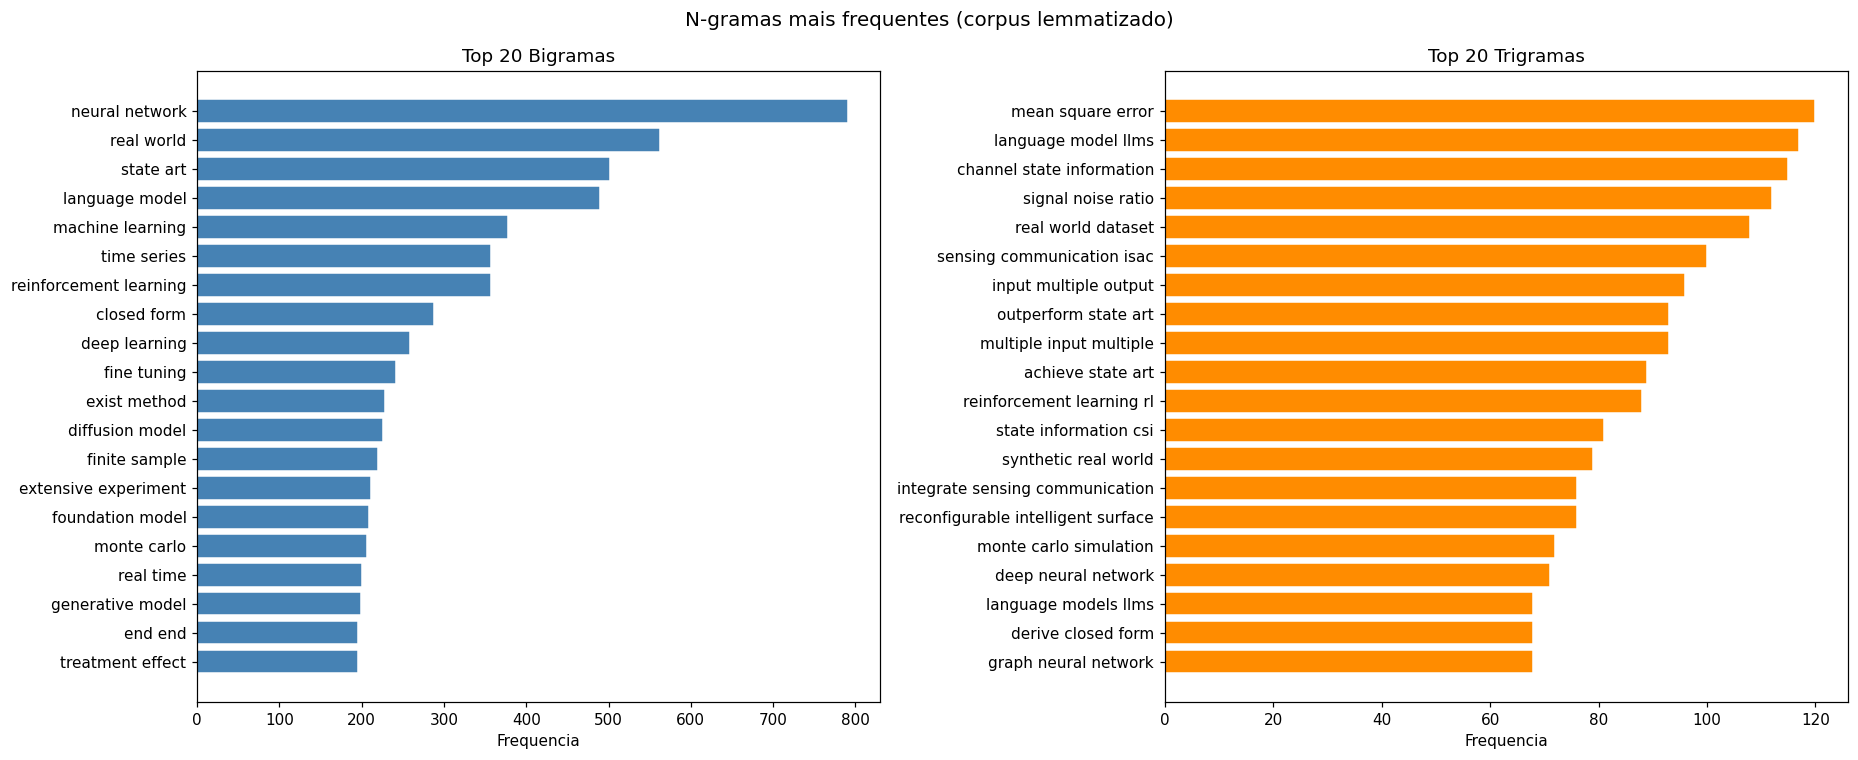

In [20]:
# ── 2.2 N-gramas ────────────────────────────────────────────────────
ng_vec    = CountVectorizer(ngram_range=(2, 3), min_df=5, max_features=60_000)
ng_matrix = ng_vec.fit_transform(corpus)

ng_names  = ng_vec.get_feature_names_out()
ng_counts = np.asarray(ng_matrix.sum(axis=0)).flatten()
ng_df = (pd.DataFrame({'ngram': ng_names, 'count': ng_counts})
           .sort_values('count', ascending=False)
           .reset_index(drop=True))

bigrams  = ng_df[ng_df['ngram'].str.count(' ') == 1].head(20)
trigrams = ng_df[ng_df['ngram'].str.count(' ') == 2].head(20)

fig, axes = plt.subplots(1, 2, figsize=(17, 7))

axes[0].barh(range(len(bigrams)), bigrams['count'].values[::-1],
             color='steelblue', edgecolor='white')
axes[0].set_yticks(range(len(bigrams)))
axes[0].set_yticklabels(bigrams['ngram'].values[::-1])
axes[0].set_title('Top 20 Bigramas', fontsize=12)
axes[0].set_xlabel('Frequencia')

axes[1].barh(range(len(trigrams)), trigrams['count'].values[::-1],
             color='darkorange', edgecolor='white')
axes[1].set_yticks(range(len(trigrams)))
axes[1].set_yticklabels(trigrams['ngram'].values[::-1])
axes[1].set_title('Top 20 Trigramas', fontsize=12)
axes[1].set_xlabel('Frequencia')

plt.suptitle('N-gramas mais frequentes (corpus lemmatizado)', fontsize=13)
plt.tight_layout()
plt.savefig('outputs/fig_ngrams.png', bbox_inches='tight')
plt.show()

## 2.3 Word2Vec — Embeddings de Palavras (Exploratório)

> **Nota de limitação (PROJECT_PLAN.md — Decisão Travada):** o corpus tem ~5 400 abstracts e ~630 000 tokens pós-pré-processamento. Word2Vec aprende relações semânticas por co-ocorrência local e produz embeddings robustos com corpora da ordem de centenas de milhões de tokens (Google News, Wikipedia). Com corpus pequeno, vizinhanças no espaço de embedding são instáveis e não capturam relações semânticas confiáveis.
>
> **Consequência de design:** Word2Vec é mantido aqui **exclusivamente como exploração visual** (demo `most_similar` + t-SNE de palavras). O motor de busca usa **TF-IDF + cosseno**; a classificação usará **features TF-IDF**. Word2Vec não entra em nenhum componente funcional do pipeline.

Configuração:
- `sg=1` (Skip-gram): aprende melhor com termos raros — adequado para vocabulário técnico.
- `vector_size=100`, `window=5`, `min_count=5`.
- `seed=42`: fixa a inicialização aleatória dos pesos. Com múltiplos workers a ordem de atualização dos gradientes depende do escalonamento de threads e não é determinística, mas resultados práticos são estáveis entre execuções com este seed.

In [ ]:
# ── 2.3 Word2Vec: treino ────────────────────────────────────────────
w2v = Word2Vec(
    sentences=token_lists,
    vector_size=100,
    window=5,
    min_count=5,
    sg=1,
    seed=42,
    workers=1,
    epochs=10,
)
print(f'Word2Vec treinado  vocabulario: {len(w2v.wv):,} termos\n')

demo_terms = ['neural', 'regression', 'bayesian', 'signal', 'spike', 'optimization']
for term in demo_terms:
    if term in w2v.wv:
        neighbors = w2v.wv.most_similar(term, topn=6)
        nb_str = ', '.join(f'{w}({s:.2f})' for w, s in neighbors)
        print(f'{term:15s}  {nb_str}')
    else:
        print(f'{term:15s}  [fora do vocabulario — min_count=5]')

Word2Vec treinado  vocabulario: 7,095 termos

neural           arnold(0.68), prototypical(0.67), anns(0.66), rnns(0.66), heaviside(0.64), isomorphism(0.64)
regression       rd(0.67), svm(0.66), cox(0.64), huber(0.64), heteroskedastic(0.64), nonparametric(0.64)
bayesian         abi(0.64), amortized(0.64), tpnn(0.62), npe(0.60), frequentist(0.59), trees(0.59)
signal           snrs(0.59), rsrp(0.59), scnr(0.57), undesired(0.56), iq(0.54), amplifier(0.53)
spike            snns(0.68), postsynaptic(0.66), rhythmic(0.64), synapsis(0.63), burst(0.63), excitatory(0.63)
optimization     ao(0.67), optimisation(0.65), maximisation(0.64), formulated(0.62), obo(0.60), subproblem(0.60)


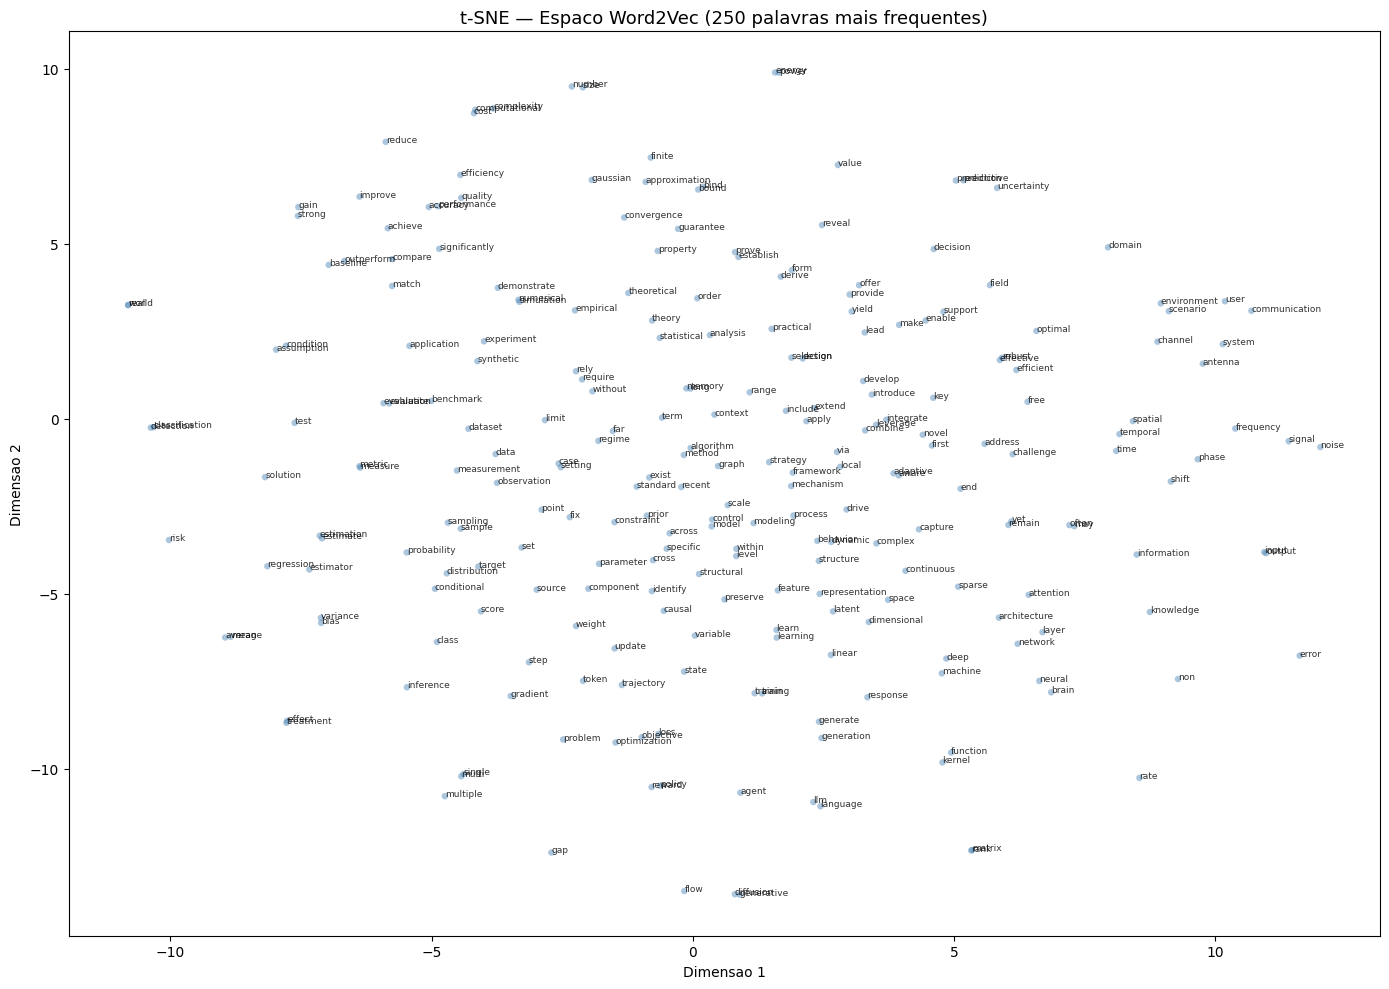

In [22]:
# ── Word2Vec: t-SNE das top-250 palavras ────────────────────────────
vocab_counts = Counter(t for toks in token_lists for t in toks)
top_words    = [w for w, _ in vocab_counts.most_common(300) if w in w2v.wv][:250]
vecs_w2v     = np.array([w2v.wv[w] for w in top_words])

tsne_w2v   = TSNE(n_components=2, random_state=42, perplexity=30,
                  max_iter=1000, learning_rate='auto', init='pca')
coords_w2v = tsne_w2v.fit_transform(vecs_w2v)

fig, ax = plt.subplots(figsize=(14, 10))
ax.scatter(coords_w2v[:, 0], coords_w2v[:, 1],
           c='steelblue', alpha=0.45, s=22, edgecolors='none')
for i, w in enumerate(top_words):
    ax.annotate(w, (coords_w2v[i, 0], coords_w2v[i, 1]), fontsize=6.5, alpha=0.80)
ax.set_title('t-SNE — Espaco Word2Vec (250 palavras mais frequentes)', fontsize=13)
ax.set_xlabel('Dimensao 1'); ax.set_ylabel('Dimensao 2')
plt.tight_layout()
plt.savefig('outputs/fig_w2v_tsne.png', bbox_inches='tight')
plt.show()

## 2.4 Similaridade por Cosseno

A similaridade por cosseno mede o ângulo entre dois vetores TF-IDF no espaço de alta dimensão, ignorando a magnitude (normaliza pelo comprimento do vetor). Documentos sobre os mesmos temas tendem a usar as mesmas palavras com pesos similares — ângulo pequeno, similaridade próxima a 1.

A preferência sobre distância euclidiana se justifica porque documentos mais longos têm vetores de maior norma; o cosseno normaliza isso implicitamente, tornando-o invariante ao comprimento do abstract.

**Demo empírico:** comparamos a distribuição de similaridade para pares dentro de `cs.LG` contra pares entre `cs.LG` e `econ.EM` — categorias metodologicamente distantes. A separação das distribuições indica que o espaço TF-IDF capturou diferenças temáticas reais.

Cosseno medio cs.LG x cs.LG   : 0.0436  (s=0.0235)
Cosseno medio cs.LG x econ.EM : 0.0280  (s=0.0176)


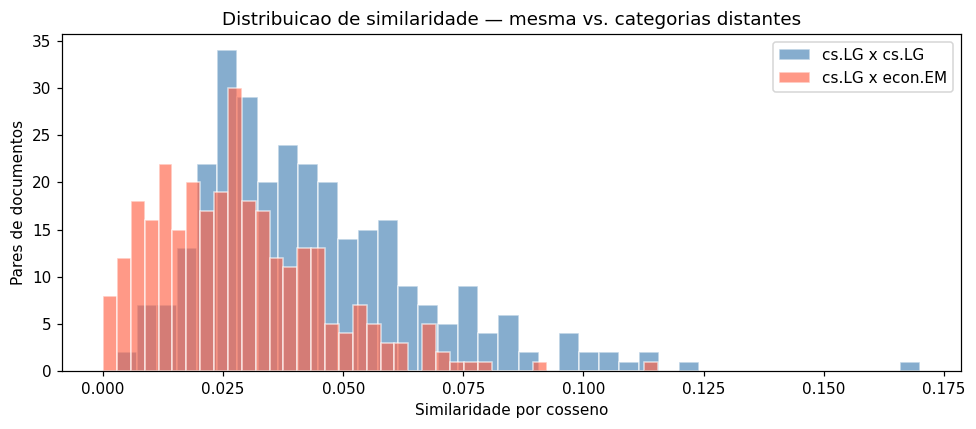

In [23]:
# ── 2.4 Similaridade por Cosseno ────────────────────────────────────
rng      = np.random.default_rng(42)
lbl_arr  = np.array(labels)
cs_idx   = np.where(lbl_arr == 'cs.LG')[0]
econ_idx = np.where(lbl_arr == 'econ.EM')[0]

same_pairs = [(int(rng.choice(cs_idx)),   int(rng.choice(cs_idx)))   for _ in range(300)]
diff_pairs = [(int(rng.choice(cs_idx)),   int(rng.choice(econ_idx))) for _ in range(300)]

def _cosine_pairs(pairs, mat):
    return [float(cosine_similarity(mat[i], mat[j])[0, 0])
            for i, j in pairs if i != j]

same_sims = _cosine_pairs(same_pairs, tfidf_matrix)
diff_sims = _cosine_pairs(diff_pairs, tfidf_matrix)

print(f'Cosseno medio cs.LG x cs.LG   : {np.mean(same_sims):.4f}  (s={np.std(same_sims):.4f})')
print(f'Cosseno medio cs.LG x econ.EM : {np.mean(diff_sims):.4f}  (s={np.std(diff_sims):.4f})')

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(same_sims, bins=40, alpha=0.65, color='steelblue',
        edgecolor='white', label='cs.LG x cs.LG')
ax.hist(diff_sims, bins=40, alpha=0.65, color='tomato',
        edgecolor='white', label='cs.LG x econ.EM')
ax.set_xlabel('Similaridade por cosseno')
ax.set_ylabel('Pares de documentos')
ax.set_title('Distribuicao de similaridade — mesma vs. categorias distantes')
ax.legend()
plt.tight_layout()
plt.savefig('outputs/fig_cosine_dist.png', bbox_inches='tight')
plt.show()

## 2.5 Motor de Busca Textual (TF-IDF + Cosseno)

O motor transforma uma consulta em linguagem livre no mesmo espaço vetorial TF-IDF do corpus e rankeia todos os documentos por similaridade de cosseno.

**Pipeline da consulta:**
1. A consulta é vetorizada com `tfidf.transform()` — o mesmo objeto fitado no corpus, **sem refitar**.
2. O vetor de consulta (1 × vocab) é comparado contra `tfidf_matrix` (5 400 × vocab) via `cosine_similarity`.
3. Os top-k documentos por score são retornados com `id`, `title`, `primary_category` e `score`.

**Por que não Word2Vec?** Média de vetores de palavras perde informação de frequência local e é instável em corpus pequeno. TF-IDF + cosseno é robusto, totalmente interpretável e demonstra performance competitiva em domínios com vocabulário técnico estável.

*Nota:* o vocabulário do vetorizador contém lemas. Termos inflectados na consulta ("networks", "forecasting") que não estão no vocabulário são ignorados silenciosamente — os termos-raiz ("neural", "time", "series", "bayesian") são suficientes para recuperação eficaz.

In [24]:
# ── 2.5 Motor de Busca ───────────────────────────────────────────────

def search(query: str, k: int = 5) -> pd.DataFrame:
    """Vetoriza a consulta com o TfidfVectorizer fitado e retorna top-k docs."""
    q_vec  = tfidf.transform([query])
    sims   = cosine_similarity(q_vec, tfidf_matrix).flatten()
    top_k  = np.argsort(sims)[::-1][:k]
    result = df.iloc[top_k][['id', 'title', 'primary_category']].copy()
    result['score'] = sims[top_k].round(4)
    result.index = range(1, k + 1)
    return result

print('Funcao search(query, k) definida. TfidfVectorizer fitado no corpus completo.')

Funcao search(query, k) definida. TfidfVectorizer fitado no corpus completo.


In [25]:
q1 = 'neural networks for time series forecasting'
print(f'Consulta 1: "{q1}"\n')
print(search(q1, k=5).to_string())

Consulta 1: "neural networks for time series forecasting"

           id                                                                                                        title primary_category   score
1  2605.00015            TimeRFT: Stimulating Generalizable Time Series Forecasting for TSFMs via Reinforcement Finetuning          eess.SP  0.2667
2  2605.01608  Why Model Selection Fails in Time Series Forecasting: An Empirical Study of Instability Across Data Regimes          eess.SP  0.2563
3  2605.14422      What if Tomorrow is the World Cup Final? Counterfactual Time Series Forecasting with Textual Conditions            cs.LG  0.2498
4  2605.10292                              LeapTS: Rethinking Time Series Forecasting as Adaptive Multi-Horizon Scheduling            cs.LG  0.2486
5  2508.20206                Filter then Attend: Improving attention-based Time Series Forecasting with Spectral Filtering            cs.LG  0.2442


In [26]:
q2 = 'bayesian uncertainty estimation'
print(f'Consulta 2: "{q2}"\n')
print(search(q2, k=5).to_string())

Consulta 2: "bayesian uncertainty estimation"

           id                                                                                                          title primary_category   score
1  2604.26673                                              Laplace Approximation for Bayesian Tensor Network Kernel Machines          stat.ML  0.2561
2  2604.12434  A Bayesian Perspective on the Role of Epistemic Uncertainty for Delayed Generalization in In-Context Learning          stat.ML  0.2531
3  2603.03035                                                                         Generalized Bayes for Causal Inference          stat.ML  0.2487
4  2605.10378                                        Uncertainty in Physics and AI: Taxonomy, Quantification, and Validation          stat.ML  0.2481
5  2501.04272                                     On weight and variance uncertainty in neural networks for regression tasks          stat.ML  0.2183


In [27]:
q3 = 'graph models of brain connectivity'
print(f'Consulta 3: "{q3}"\n')
print(search(q3, k=5).to_string())

Consulta 3: "graph models of brain connectivity"

           id                                                                                                                                  title primary_category   score
1  2505.24125                                                          Weak structural connectivity nonlinearly underlying human cognitive abilities         q-bio.NC  0.2476
2  2603.22296                                                                                                      Sketching a Space of Brain States         q-bio.NC  0.1937
3  2509.09696  DCHO: A Decomposition-Composition Framework for Predicting Higher-Order Brain Connectivity to Enhance Diverse Downstream Applications         q-bio.NC  0.1914
4  2508.16414            NeuroKoop: Neural Koopman Fusion of Structural-Functional Connectomes for Identifying Prenatal Drug Exposure in Adolescents         q-bio.NC  0.1878
5  2510.03306                                                                   

### Avaliação das Consultas

**Consulta 1 — "neural networks for time series forecasting"**
Esperamos resultados predominantemente de `cs.LG` e `stat.ML`, com foco em arquiteturas sequenciais (RNN, LSTM, Transformer) aplicadas a séries temporais. A presença de `eess.SP` é plausível — processamento de sinais trabalha com dados sequenciais em contextos diferentes (áudio, radar). Um resultado de `econ.EM` indicaria um abstract econométrico com linguagem próxima à de deep learning.

**Consulta 2 — "bayesian uncertainty estimation"**
`stat.ML` deve dominar (inferência bayesiana, variational inference, processos gaussianos). `cs.LG` pode aparecer com Bayesian deep learning. `econ.EM` tem tradição bayesiana forte em econometria — sua presença seria coerente e revela a circulação desse ferramental entre domínios.

**Consulta 3 — "graph models of brain connectivity"**
`q-bio.NC` deve dominar (modelos de conectoma, redes de coativação, dinâmica neural em grafos). `cs.LG` pode aparecer com Graph Neural Networks — este caso testa a capacidade do motor de distinguir neurociência computacional de GNNs para fins gerais. Resultados mistos aqui revelam o vocabulário compartilhado entre as duas áreas.

## 2.6 t-SNE dos Vetores TF-IDF por Documento

Projeção t-SNE do espaço TF-IDF (até 20 000 dimensões) para 2D. O t-SNE preserva estrutura local: documentos vizinhos no espaço de alta dimensão tendem a ficar próximos na projeção.

**Interpretação esperada:** categorias com vocabulário muito distinto (`q-bio.NC`, `econ.EM`) devem formar aglomerados mais coesos. `cs.LG` e `stat.ML` provavelmente se sobreporão — compartilham extenso vocabulário metodológico. Zonas de sobreposição são achados analíticos: indicam onde o corpus reflete a circulação de métodos entre disciplinas — narrativa central do projeto.

**Implementação:** `TruncatedSVD` de 20 000 → 50 dimensões (reduz ruído e acelera o t-SNE preservando variância dominante), seguido de t-SNE de 50 → 2 dimensões. Amostra de 2 000 documentos para viabilidade computacional.

TruncatedSVD: variancia explicada (50 comp.) = 0.127


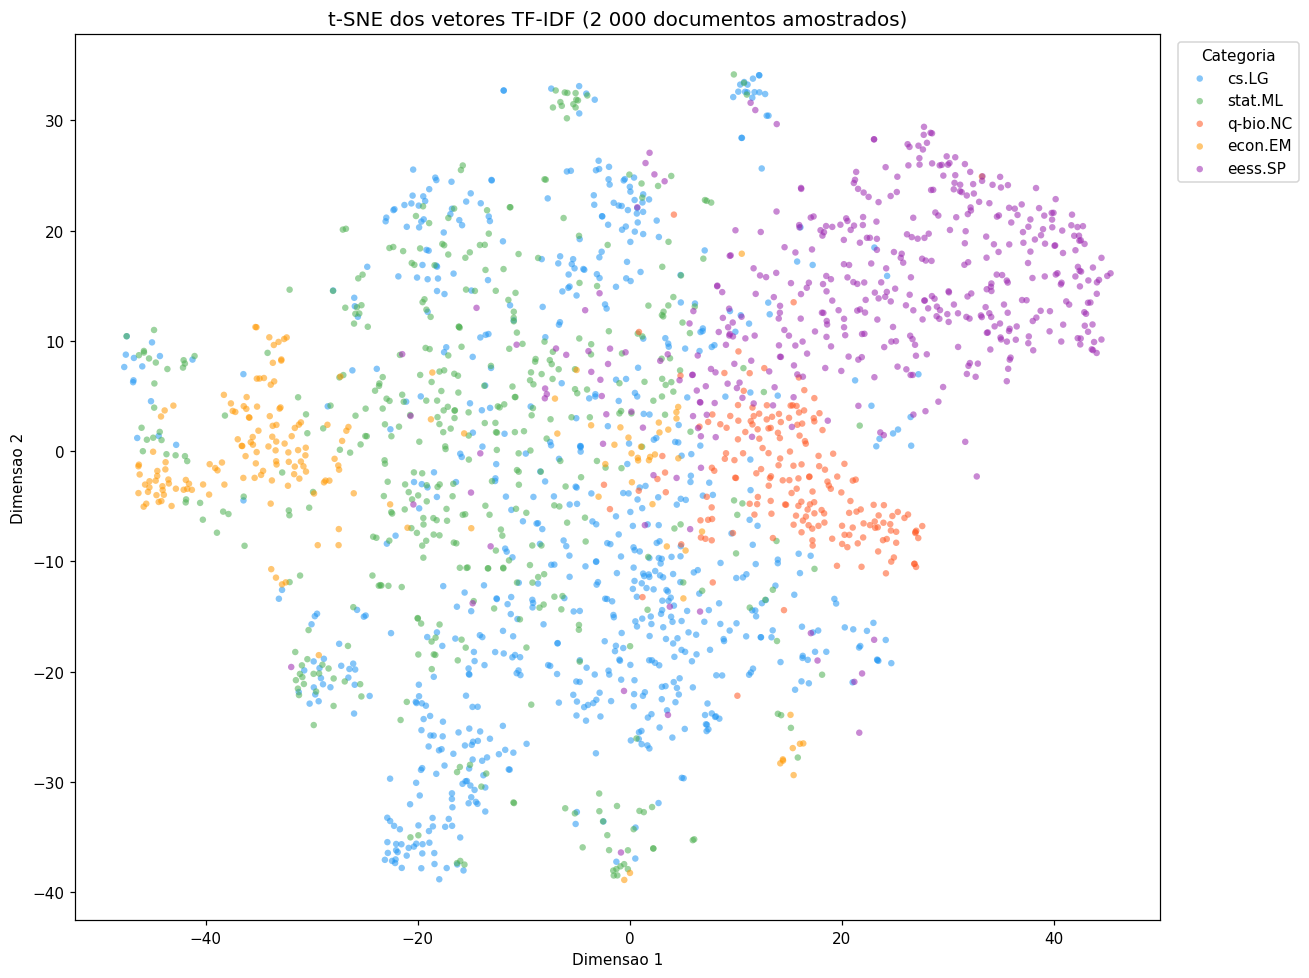

In [28]:
# ── 2.6 t-SNE dos vetores TF-IDF ────────────────────────────────────
N_SAMPLE   = 2_000
rng2       = np.random.default_rng(42)
sample_idx = rng2.choice(len(df), size=N_SAMPLE, replace=False)

X_sample = tfidf_matrix[sample_idx]
y_sample = [labels[i] for i in sample_idx]

svd  = TruncatedSVD(n_components=50, random_state=42)
X_50 = svd.fit_transform(X_sample)
print(f'TruncatedSVD: variancia explicada (50 comp.) = {svd.explained_variance_ratio_.sum():.3f}')

tsne_doc = TSNE(n_components=2, random_state=42, perplexity=40,
                max_iter=1000, learning_rate='auto', init='pca')
X_2d = tsne_doc.fit_transform(X_50)

cat_list = ['cs.LG', 'stat.ML', 'q-bio.NC', 'econ.EM', 'eess.SP']
palette  = ['#2196F3', '#4CAF50', '#FF5722', '#FF9800', '#9C27B0']

fig, ax = plt.subplots(figsize=(12, 9))
for cat, color in zip(cat_list, palette):
    mask = np.array([c == cat for c in y_sample])
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               c=color, label=cat, alpha=0.55, s=18, edgecolors='none')

ax.set_title('t-SNE dos vetores TF-IDF (2 000 documentos amostrados)', fontsize=13)
ax.legend(title='Categoria', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.set_xlabel('Dimensao 1'); ax.set_ylabel('Dimensao 2')
plt.tight_layout()
plt.savefig('outputs/fig_tsne_tfidf.png', bbox_inches='tight')
plt.show()

## Saída da Fase 2

Artefatos persistidos em `outputs/`:

| Arquivo | Conteúdo |
|---|---|
| `tfidf_vectorizer.joblib` | `TfidfVectorizer` fitado no corpus completo |
| `tfidf_matrix.npz` | Matriz TF-IDF esparsa (5 400 × vocab) |
| `fig_ngrams.png` | Top 20 bigramas e trigramas |
| `fig_w2v_tsne.png` | t-SNE do espaço Word2Vec (250 palavras) |
| `fig_cosine_dist.png` | Distribuição de similaridade por cosseno |
| `fig_tsne_tfidf.png` | t-SNE dos documentos TF-IDF por categoria |

**Motor de busca** (`search(query, k)`) disponível no namespace do notebook.

**Nota para Fase 3:** na classificação supervisionada, o `TfidfVectorizer` será **refitado apenas no conjunto de treino** para evitar vazamento de dados (data leakage). O artefato salvo aqui serve exclusivamente para busca e visualizações desta fase.